(2, 4)
                  from                     to         subject  \
0  sender1@example.com  recipient@example.com  Test Subject 1   
1  sender2@example.com  recipient@example.com  Test Subject 2   

                              date  
0  Mon, 26 Jun 2023 10:00:00 -0400  
1  Mon, 26 Jun 2023 11:00:00 -0400  
Total emails: 2
                       from                     to         subject  \
count                     2                      2               2   
unique                    2                      1               2   
top     sender1@example.com  recipient@example.com  Test Subject 1   
freq                      1                      2               1   
mean                    NaN                    NaN             NaN   
min                     NaN                    NaN             NaN   
25%                     NaN                    NaN             NaN   
50%                     NaN                    NaN             NaN   
75%                     NaN             

/tmp/ipykernel_8127/1581847188.py:45: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['date'].dt.to_period('M')


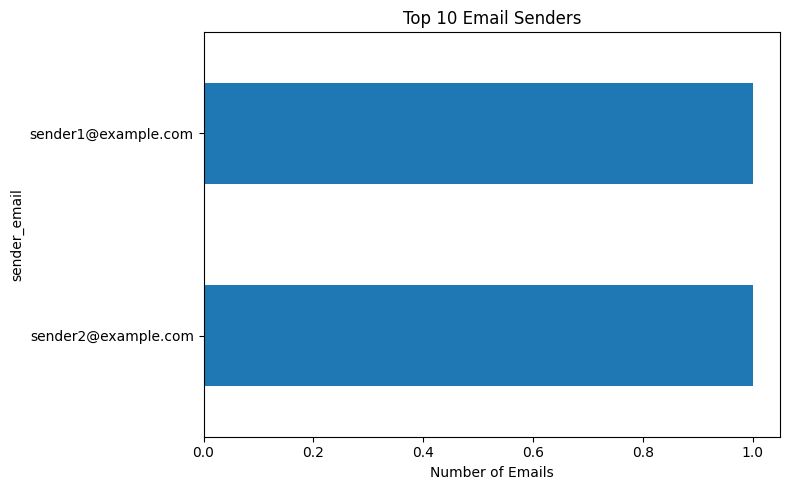

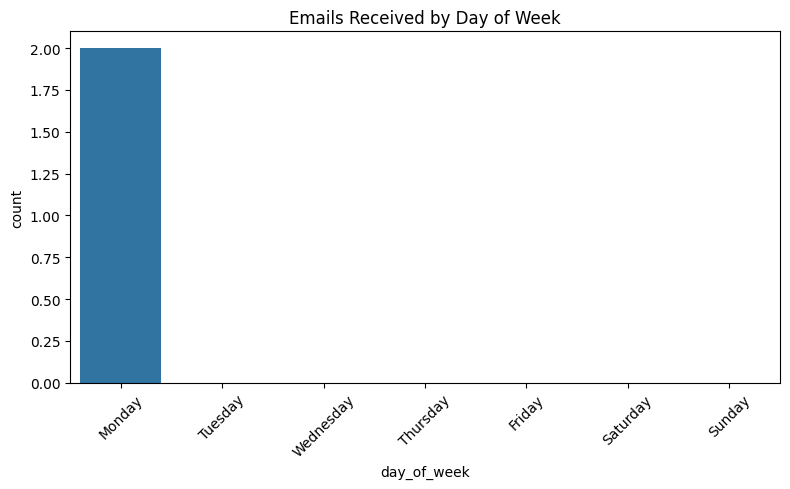

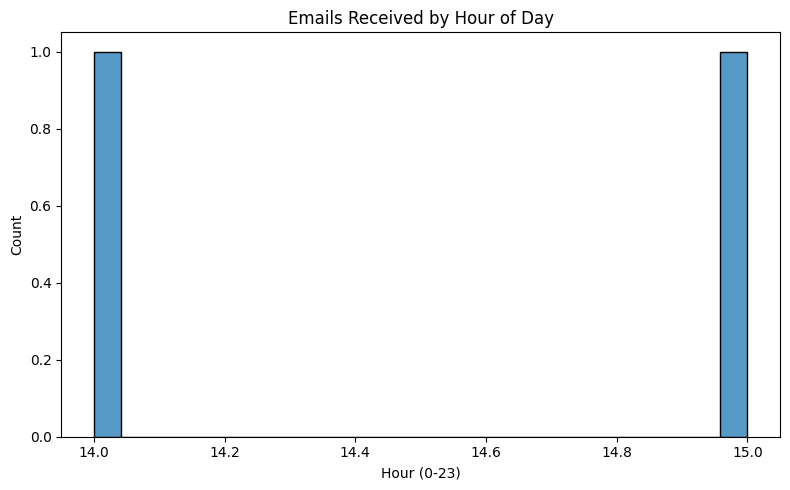

/usr/local/lib/python3.13/dist-packages/pandas/plotting/_matplotlib/core.py:1567: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


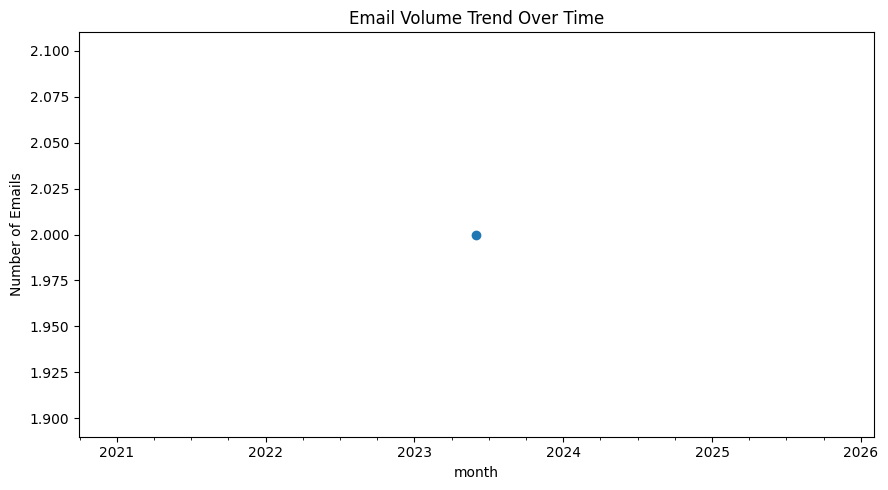

In [11]:

import mailbox
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Parse the exported .mbox file
mbox = mailbox.mbox('inbox.mbox')

records = []

for message in mbox:
    records.append({
        'from': message.get('From'),
        'to': message.get('To'),
        'subject': message.get('Subject'),
        'date': message.get('Date')
    })

# Step 2: Build DataFrame
df = pd.DataFrame(records)

print(df.shape)
print(df.head())

# Step 3: Clean the data
df['date'] = pd.to_datetime(
    df['date'], errors='coerce', utc=True
)

df = df.dropna(subset=['date'])

df['subject'] = df['subject'].fillna('(no subject)')

# Updated regex to handle both bracketed "Name <email>" and raw "email" formats
df['sender_email'] = df['from'].str.extract(r'<?([a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,})>?')

df['sender_domain'] = df['sender_email'].str.split('@').str[1]

df = df.drop_duplicates()

# Step 4: Derived time features
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.to_period('M')

# Step 5: EDA
print('Total emails:', len(df))
print(df.describe(include='all'))
print(df.isnull().sum())

# Step 6: Top senders and domains
top_senders = df['sender_email'].dropna().value_counts().head(10)
top_domains = df['sender_domain'].dropna().value_counts().head(10)

print("Top Senders:\n", top_senders)
print("Top Domains:\n", top_domains)

# Step 7: Visualizations

if not top_senders.empty:
    plt.figure(figsize=(8, 5))
    top_senders.plot(kind='barh')
    plt.title('Top 10 Email Senders')
    plt.xlabel('Number of Emails')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No sender email data available to plot Top Senders.")

if not df.empty:
    plt.figure(figsize=(8, 5))
    sns.countplot(
        x='day_of_week',
        data=df,
        order=[
            'Monday', 'Tuesday', 'Wednesday',
            'Thursday', 'Friday', 'Saturday', 'Sunday'
        ]
    )
    plt.title('Emails Received by Day of Week')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.histplot(df['hour'], bins=24, kde=False)
    plt.title('Emails Received by Hour of Day')
    plt.xlabel('Hour (0-23)')
    plt.tight_layout()
    plt.show()

    monthly_counts = df.groupby('month').size()
    if not monthly_counts.empty:
        plt.figure(figsize=(9, 5))
        monthly_counts.plot(kind='line', marker='o')
        plt.title('Email Volume Trend Over Time')
        plt.ylabel('Number of Emails')
        plt.tight_layout()
        plt.show()
